# Testing and regularization

In [87]:
!git clone https://github.com/s7s/machine_learning_1.git
%cd  machine_learning_1/polynomial_regression

Cloning into 'machine_learning_1'...
remote: Enumerating objects: 378, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (125/125), done.
remote: Total 378 (delta 74), reused 3 (delta 1), pack-reused 252 (from 1)
Receiving objects: 100% (378/378), 42.71 MiB | 20.78 MiB/s, done.
Resolving deltas: 100% (197/197), done.
/content/machine_learning_1/polynomial_regression/machine_learning_1/polynomial_regression


In [88]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
random.seed(0)

## Defining our dataset

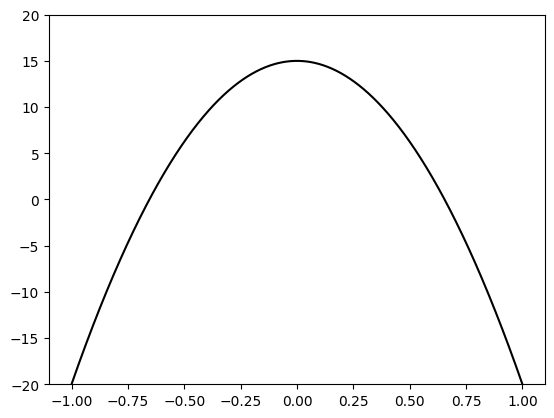

In [89]:
# Our original polynomial is -35x^2+x+15
coefs = [15,0,-35]

def polynomial(coefs, x):
    n = len(coefs)
    return sum([coefs[i]*x**i for i in range(n)])

def draw_polynomial(coefs):
    n = len(coefs)
    x = np.linspace(-1, 1, 1000)
    plt.ylim(-20,20)
    plt.plot(x, sum([coefs[i]*x**i for i in range(n)]), linestyle='-', color='black')

draw_polynomial(coefs)

In [90]:
X = []
Y = []
for i in range(40):
    x = random.uniform(-1,1)
    y = polynomial(coefs, x) + random.gauss(0,2)
    X.append(x)
    Y.append(y)
X=np.array(X)
Y=np.array(Y)

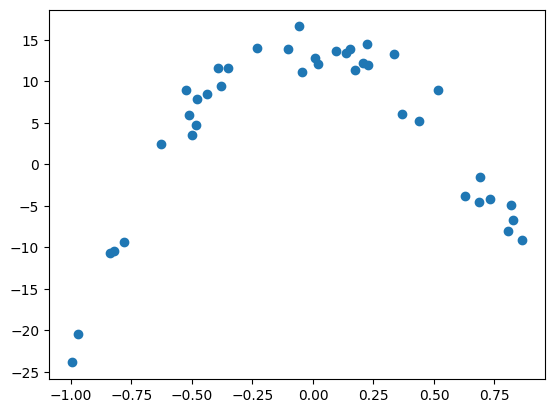

In [91]:
plt.scatter(X, Y)
#draw_polynomial(coefs)

## Training a polynomial regression model

In [92]:
for datasample in zip(X,Y):
    print(datasample)

(np.float64(0.6888437030500962), np.float64(-1.503313676546703))
(np.float64(-0.4821664994140733), np.float64(4.776223391096098))
(np.float64(0.02254944273721704), np.float64(12.087957039273702))
(np.float64(-0.3933745478421451), np.float64(11.552655381342872))
(np.float64(-0.04680609169528838), np.float64(11.13939451533042))
(np.float64(0.009373711634780513), np.float64(12.810729063756577))
(np.float64(-0.43632431120059234), np.float64(8.437955069843738))
(np.float64(-0.4989873172751189), np.float64(3.511211911084044))
(np.float64(0.8194925119364802), np.float64(-4.879955934160179))
(np.float64(0.8043319008791654), np.float64(-8.0368585173616))
(np.float64(-0.37970486136133474), np.float64(9.412786903432224))
(np.float64(0.36796786383088254), np.float64(6.014161594638752))
(np.float64(-0.055714569094573285), np.float64(16.612588226930765))
(np.float64(0.2217739468876032), np.float64(14.540743210654112))
(np.float64(0.8260221064757964), np.float64(-6.653701461777612))
(np.float64(0.730

### Adding columns to our dataset corresponding to $x^2, x^3, \ldots, x^{200}$

In [93]:
#fit polynomial into linear
from sklearn.preprocessing import PolynomialFeatures
def addPoly(X,polyDegree):
    x_reshaped = X.reshape(-1,1)
    poly=PolynomialFeatures(degree=polyDegree,include_bias=False)
    X = poly.fit_transform(x_reshaped)
    return X
X_poly=addPoly(X,200)

In [94]:
print(X_poly.shape)
print(X_poly[0,:])

(40, 200)
[6.88843703e-01 4.74505647e-01 3.26860227e-01 2.25155609e-01
 1.55097024e-01 1.06837608e-01 7.35944136e-02 5.06950484e-02
 3.49209649e-02 2.40550867e-02 1.65701950e-02 1.14142745e-02
 7.86265112e-03 5.41613771e-03 3.73087236e-03 2.56998793e-03
 1.77032000e-03 1.21947379e-03 8.40026839e-04 5.78647198e-04
 3.98597479e-04 2.74571363e-04 1.89136755e-04 1.30285662e-04
 8.97464582e-05 6.18212826e-05 4.25852012e-05 2.93345477e-05
 2.02069185e-05 1.39194085e-05 9.58829693e-06 6.60483796e-06
 4.54970104e-06 3.13403291e-06 2.15885884e-06 1.48711632e-06
 1.02439071e-06 7.05645090e-07 4.86079177e-07 3.34832580e-07
 2.30647314e-07 1.58879950e-07 1.09443453e-07 7.53894335e-08
 5.19315366e-08 3.57727120e-08 2.46418074e-08 1.69743538e-08
 1.16926768e-08 8.05442676e-09 5.54824115e-09 3.82187098e-09
 2.63267176e-09 1.81349936e-09 1.24921762e-09 8.60515689e-10
 5.92760814e-10 4.08319554e-10 2.81268354e-10 1.93749934e-10
 1.33463422e-10 9.19354380e-11 6.33291475e-11 4.36238845e-11
 3.00500381e-1

## Splitting data into training and testing

In [95]:
from sklearn.model_selection import train_test_split
# use sklearn (train_test_split) to split data to 80% training 20% testing
X_train, X_test, y_train, y_test = train_test_split(X_poly , Y ,train_size = 0.8 , test_size = 0.2)

In [96]:
from sklearn.metrics import mean_squared_error
def display_results(model):
    coefs = [model.intercept_]
    coefs += list(model.coef_)
    ytrain_predict=model.predict(X_train)
    ytest_predict=model.predict(X_test)
    train_error=np.sqrt(mean_squared_error(y_train,ytrain_predict))
    test_error=np.sqrt(mean_squared_error(y_test,ytest_predict))
    print("Training error (rmse):", train_error)
    print("Testing error (rmse):", test_error)
    plt.scatter(X_train[:,0], y_train, marker='o')
    plt.scatter(X_test[:,0], y_test, marker='^')
    draw_polynomial(coefs)
    plt.show()
    print("Polynomial coefficients")
    print(coefs)

## Training a polynomial regression model with no regularization

In [97]:
from sklearn.linear_model import LinearRegression
## TODO ##
# use sklearn linear regression to fit the data
model_no_reg = LinearRegression()
model_no_reg.fit(X_train,y_train)


LinearRegression()

Training error (rmse): 0.5911461269203877
Testing error (rmse): 10985373.630545266


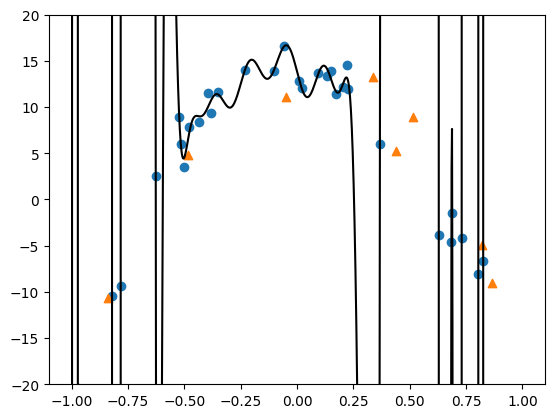

Polynomial coefficients
[np.float64(13.859970045353274), np.float64(-95.35546163865858), np.float64(-11.480666829661809), np.float64(18717.203586531217), np.float64(13831.946829197177), np.float64(-1250711.2061886769), np.float64(-1674354.566422704), np.float64(37473796.61152379), np.float64(69155895.5926928), np.float64(-554538159.1156766), np.float64(-1267888804.868762), np.float64(4087020569.383569), np.float64(11064094837.09974), np.float64(-14786467458.121931), np.float64(-47975835081.38809), np.float64(24485544879.63534), np.float64(101253975404.18431), np.float64(-12800219565.28307), np.float64(-75221816923.66563), np.float64(380499403.33536375), np.float64(-46456396026.3572), np.float64(-12029959260.429451), np.float64(46650851553.61562), np.float64(-6603710512.961072), np.float64(56838834451.965126), np.float64(14283713193.878485), np.float64(10353115000.977505), np.float64(23266363353.871162), np.float64(-31278392184.026463), np.float64(13600987041.36889), np.float64(-4348094

In [98]:
display_results(model_no_reg)

## Training a polynomial regression model with L1 regularization

In [99]:
from sklearn import linear_model
from sklearn.linear_model import Lasso
## TODO ##
# use sklearn Lasso (linear regression with L1 Norm) to fit the data
model_L1_reg = Lasso(alpha=0.1)
model_L1_reg.fit(X_train , y_train)

Lasso(alpha=0.1)

Training error (rmse): 1.8358643336540652
Testing error (rmse): 2.7772513273137864


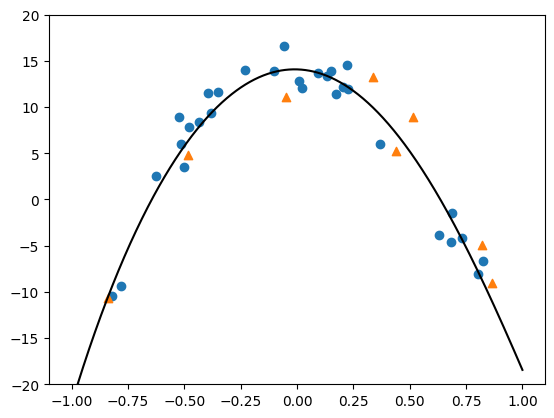

Polynomial coefficients
[np.float64(14.079940397202375), np.float64(-0.7045134725274379), np.float64(-34.37162189092523), np.float64(0.0), np.float64(-0.0), np.float64(2.5517929425247385), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.float64(-0.0), np.float64(0.0), np.flo

In [100]:
display_results(model_L1_reg)

## Training a polynomial regression model with L2 regularization

In [101]:
from sklearn import linear_model
from sklearn.linear_model import Ridge
## TODO ##
# use sklearn Ridge (linear regression with L2 Norm) to fit the data
model_L2_reg = Ridge(alpha=0.1)
model_L2_reg.fit(X_train,y_train)

Ridge(alpha=0.1)

Training error (rmse): 1.6689730562675793
Testing error (rmse): 2.920994163873301


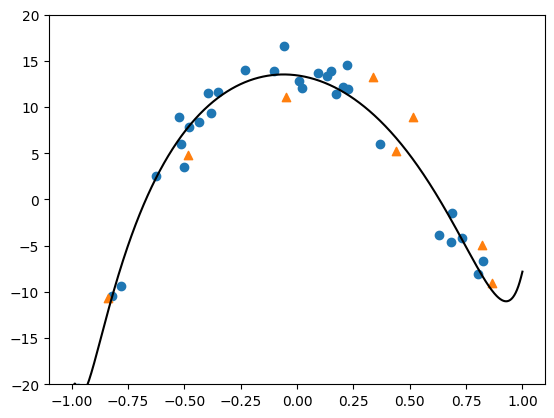

Polynomial coefficients
[np.float64(13.434714020419591), np.float64(-3.236510196490727), np.float64(-26.994382067737615), np.float64(1.9630173350550928), np.float64(-9.53379438076017), np.float64(3.6413824362376026), np.float64(-2.5724149924235498), np.float64(3.226978464277738), np.float64(0.029159028356977146), np.float64(2.298245867545238), np.float64(0.9661826325595806), np.float64(1.417180754117676), np.float64(1.245118849247639), np.float64(0.7341574959964992), np.float64(1.2634029359621002), np.float64(0.2521655103615066), np.float64(1.1847742794054383), np.float64(-0.06845346956023857), np.float64(1.0774074907323286), np.float64(-0.2713977675018602), np.float64(0.9688778390128916), np.float64(-0.39268912397823064), np.float64(0.8692714081958901), np.float64(-0.45897429873683504), np.float64(0.7812348947230121), np.float64(-0.4889601747295087), np.float64(0.7044167436931095), np.float64(-0.495414463562192), np.float64(0.6374249246113151), np.float64(-0.48691119559074414), np.flo

In [102]:
display_results(model_L2_reg)

## Viewing the predictions in the testing set

In [103]:
import pandas as pd
from IPython.display import display
predictions={}
predictions ['x']=X_test[:,0]
predictions ['y']=y_test
predictions['No reg'] = model_no_reg.predict(X_test)
predictions['L1 reg'] = model_L1_reg.predict(X_test)
predictions['L2 reg'] = model_L2_reg.predict(X_test)
predictions=pd.DataFrame.from_dict(predictions)
display(predictions)

,x,y,No reg,L1 reg,L2 reg
0,0.819493,-4.879956,-9.856771e+04,-8.637156,-8.162647
1,0.336306,13.258006,-2.328928e+02,9.966487,9.259522
2,-0.482166,4.776223,6.633855e+00,6.362261,7.834599
3,0.865668,-9.073495,3.053931e+07,-11.046843,-9.871501
4,-0.046806,11.139395,1.669214e+01,14.037614,13.526815
5,0.439409,5.238271,5.285424e+03,7.175679,6.664902
6,0.515208,8.950653,1.788352e+04,4.686028,4.322756
7,-0.839108,-10.658485,5.724261e+06,-10.591592,-12.191702


### Real Example (Predict fuel efficiency)

In [104]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [105]:
#### Get data

url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

raw_dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

dataset = raw_dataset.copy()

#### Clean data

dataset.isna().sum()

dataset = dataset.dropna()

dataset.isna().sum()

dataset.head()

dataset['Origin'] = dataset['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})

dataset = pd.get_dummies(dataset, columns=['Origin'], prefix='', prefix_sep='')

dataset.head()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,False,False,True
1,15.0,8,350.0,165.0,3693.0,11.5,70,False,False,True
2,18.0,8,318.0,150.0,3436.0,11.0,70,False,False,True
3,16.0,8,304.0,150.0,3433.0,12.0,70,False,False,True
4,17.0,8,302.0,140.0,3449.0,10.5,70,False,False,True


In [106]:
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

#### using 50th order

In [107]:
from sklearn import preprocessing

X_train=train_dataset[['Horsepower']]
y_train=train_dataset[['MPG']]

X_test=test_dataset[['Horsepower']]
y_test=test_dataset[['MPG']]

from sklearn.preprocessing import PolynomialFeatures
def addPoly(X,polyDegree):
    poly = PolynomialFeatures(polyDegree,include_bias=False)
    X=poly.fit_transform(X)
    return X

X_trainPoly=addPoly(X_train,50)
X_testPoly=addPoly(X_test,50)
scaler=preprocessing.StandardScaler().fit(X_trainPoly)

X_trainPoly=scaler.transform(X_trainPoly)
X_testPoly=scaler.transform(X_testPoly)

##### no regularization

In [108]:
# no regularization
from sklearn.linear_model import LinearRegression
model_no_reg = LinearRegression()
model_no_reg.fit(X_trainPoly, y_train)
ytest_predict=model_no_reg.predict(X_testPoly)
test_error=np.sqrt(mean_squared_error(y_test,ytest_predict))
print(test_error)

3062.854825643221


##### lasso regularization

In [109]:
# lasso regularization
from sklearn import linear_model
model_L1_reg = linear_model.Lasso(alpha=0.5)
model_L1_reg.fit(X_trainPoly, y_train)
ytest_predict=model_L1_reg.predict(X_testPoly)
test_error=np.sqrt(mean_squared_error(y_test,ytest_predict))
print(test_error)

4.383251699910778


##### ridge regularization

In [110]:
# ridge regularization
from sklearn import linear_model
model_L2_reg = linear_model.Ridge(alpha=0.5)
model_L2_reg.fit(X_trainPoly, y_train)
ytest_predict=model_L2_reg.predict(X_testPoly)
test_error=np.sqrt(mean_squared_error(y_test,ytest_predict))
print(test_error)

4.210997782920176
